In [27]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

Loading the necessary columns from the table "supply_chain_data" of the SupplyChainDB database

In [ ]:
server = r'LAPTOP-OCKRNGU5\SQLEXPRESS'
database = 'SupplyChainDB'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

query = """
SELECT
  order_id,
  order_customer_id AS customer_id,
  order_date_dateorders AS order_datetime,
  shipping_date_dateorders AS shipping_datetime,
  days_for_shipment_scheduled AS scheduled_ship_days,
  days_for_shipping_real AS actual_ship_days,
  (days_for_shipping_real - days_for_shipment_scheduled) AS shipping_delay_days,
  CASE
    WHEN late_delivery_risk IS NOT NULL THEN late_delivery_risk
    WHEN (days_for_shipping_real - days_for_shipment_scheduled) > 0 THEN 1
    ELSE 0
  END AS is_late_flag,
  delivery_status,
  shipping_mode,
  order_status,
  order_region,
  order_state,
  market,
  order_country,
  order_city,
  product_category_id,
  category_name,
  order_item_product_price,
  order_item_quantity,
  order_item_discount,
  order_item_discount_rate,
  order_item_total,
  sales,
  benefit_per_order,
  order_profit_per_order,
  order_item_profit_ratio,
  CASE
    WHEN sales = 0 OR sales IS NULL THEN NULL
    ELSE ROUND(order_profit_per_order / NULLIF(sales, 0), 6)
  END AS profit_margin,
  DATEPART(year, order_date_dateorders) AS order_year,
  DATEPART(month, order_date_dateorders) AS order_month,
  DATEPART(weekday, order_date_dateorders) AS order_weekday
FROM dbo.supply_chain_data
WHERE
  days_for_shipping_real IS NOT NULL
  AND days_for_shipment_scheduled IS NOT NULL
  AND (order_profit_per_order IS NOT NULL OR sales IS NOT NULL);
"""

supply_chain = pd.read_sql(query, engine)
supply_chain.style

## Calculating for the total order, percentage of late orders, average profit, and total sum of profit per shipping mode

In [29]:
query = """
SELECT 
         shipping_mode
       , COUNT(*) as total_orders
       , AVG(CAST(late_delivery_risk AS FLOAT)) * 100 as late_rate_pct
       , AVG(benefit_per_order) as avg_profit
       , SUM(benefit_per_order) as sum_profit
FROM dbo.supply_chain_data
GROUP BY shipping_mode
ORDER BY late_rate_pct DESC;
"""

df = pd.read_sql(query, engine)
df.style

,shipping_mode,total_orders,late_rate_pct,avg_profit,sum_profit
0,First Class,27814,95.322499,23.122238,643121.920739
1,Second Class,35216,76.632781,21.305889,750308.170265
2,Same Day,9737,45.743042,20.850203,203018.430242
3,Standard Class,107752,38.071683,21.999169,2370454.452804


On average, 'First Class' shipping generates the most profit while 'Same Day' generates the least.

## Calculating for which Shipping Mode generates the most 'negative' profit

In [30]:
query = """
SELECT 
         shipping_mode
       , COUNT(*) as total_orders
       , AVG(CAST(late_delivery_risk AS FLOAT)) * 100 as late_rate_pct
       , AVG(benefit_per_order) as avg_profit
       , SUM(benefit_per_order) as sum_profit
FROM dbo.supply_chain_data
WHERE benefit_per_order < 0
GROUP BY shipping_mode
ORDER BY avg_profit;
"""

df = pd.read_sql(query, engine)
df.style

,shipping_mode,total_orders,late_rate_pct,avg_profit,sum_profit
0,Second Class,6529,76.887732,-118.752215,-775333.209136
1,Standard Class,20318,38.547101,-114.453963,-2325475.627709
2,Same Day,1835,47.356948,-112.862616,-207102.899651
3,First Class,5102,94.707958,-112.825482,-575635.609272


In total, 'Standard Class' shipping generated the most loss, while on average 'Second Class' generated the most loss.

## Finding in which 'Month' does profit dips and peaks

(15.0, 30.0)

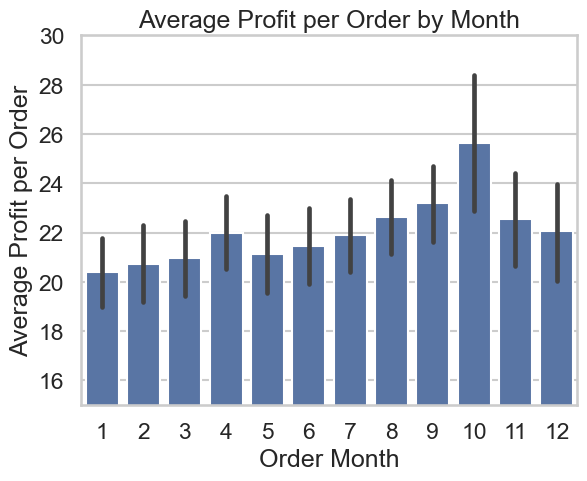

In [35]:
ax =sns.barplot(
            data=supply_chain,
            x='order_month',
            y='benefit_per_order'
)
ax.set_title('Average Profit per Order by Month')
ax.set_xlabel('Order Month')
ax.set_ylabel('Average Profit per Order')
ax.set_ylim(15, 30)

The month of October has generated the most profit across 2015 to 2018